In [7]:
!pip install transformers accelerate -q

In [8]:
!pip install torch transformers accelerate scikit-learn matplotlib seaborn pandas

In [9]:
from huggingface_hub import login

In [10]:
login()

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModelForCausalLM

In [12]:
MODEL_NAME = "Qwen/Qwen3-8B"

In [13]:
queries = {
    "parcel": [
        "Look up cadastral unit 0301-1/2 in the property registry",
        "Find property details for cadastre number 1601-5/3",
        "Get the cadastral record for 0219-22/7",
    ],
    "address": [
        "What address is closest to 59.8939, 10.6450?",
        "Reverse geocode the position 58.9700, 5.7331",
        "Find the street address at coordinates 63.4297, 10.3933",
    ],
    "municipality": [
        "What municipality is at 59.9139 N, 10.7522 E?",
        "Which municipality does coordinate 60.3913, 5.3221 belong to?",
        "Find the municipality for GPS position 63.4305, 10.3951",
    ],
}

variants = {
    "A_no_namespace": {
        "get_parcel": queries["parcel"],
        "get_address": queries["address"],
        "get_municipality": queries["municipality"],
    },
    "B_domain_namespace": {
        "cadastre_get_parcel": queries["parcel"],
        "address_get_address": queries["address"],
        "admin_get_municipality": queries["municipality"],
    },
    "C_shared_action_prefix": {
        "lookup_parcel": queries["parcel"],
        "lookup_address": queries["address"],
        "lookup_municipality": queries["municipality"],
    },
}

In [14]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.bfloat16, device_map="auto")
model.eval()

config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 4096)
    (layers): ModuleList(
      (0-35): 36 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=4096, out_features=12288, bias=False)
          (up_proj): Linear(in_features=4096, out_features=12288, bias=False)
          (down_proj): Linear(in_features=12288, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((4096,), eps=1e-06)
        (post_attention_la

In [15]:
print(f"Device: {next(model.parameters()).device}")
print(f"Layers: {model.config.num_hidden_layers}")
print(f"d_model: {model.config.hidden_size}")

Device: cuda:0
Layers: 36
d_model: 4096


In [16]:
def make_prompt(tool_name, query, all_tool_names):
    tool_list = "\n".join([f"- {t}()" for t in all_tool_names])
    messages = [
        {
            "role": "user",
            "content": (
                f"You have access to these tools:\n"
                f"{tool_list}\n\n"
                f"User: {query}\n"
                f"Tool: /no_think"
            )
        }
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

In [17]:
def get_residual_activation(prompt, layer_idx=-2):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    hidden = outputs.hidden_states[layer_idx]
    return hidden[0, -1, :].float().cpu().numpy()

In [32]:
all_results = {}

for variant_name, tools in variants.items():
    print(f"\nProcessing variant: {variant_name}")
    tool_names = list(tools.keys())
    tool_means = {}

    for tool_name, tool_queries in tools.items():
        activations = []
        for query in tool_queries:
            try:
                prompt = make_prompt(tool_name, query, tool_names)
                act = get_residual_activation(prompt)
                activations.append(act)
                print(f"  ✓ {tool_name} — query ok, shape {act.shape}")
            except Exception as e:
                print(f"  ✗ {tool_name} — FAILED: {e}")

        if activations:
            tool_means[tool_name] = np.mean(activations, axis=0)
        else:
            print(f"  !! No activations collected for {tool_name}")

    all_results[variant_name] = tool_means

print("\nVariants collected:", list(all_results.keys()))
print("Tools per variant:", {k: list(v.keys()) for k, v in all_results.items()})


Processing variant: A_no_namespace
  ✓ get_parcel — query ok, shape (4096,)
  ✓ get_parcel — query ok, shape (4096,)
  ✓ get_parcel — query ok, shape (4096,)
  ✓ get_address — query ok, shape (4096,)
  ✓ get_address — query ok, shape (4096,)
  ✓ get_address — query ok, shape (4096,)
  ✓ get_municipality — query ok, shape (4096,)
  ✓ get_municipality — query ok, shape (4096,)
  ✓ get_municipality — query ok, shape (4096,)

Processing variant: B_domain_namespace
  ✓ cadastre_get_parcel — query ok, shape (4096,)
  ✓ cadastre_get_parcel — query ok, shape (4096,)
  ✓ cadastre_get_parcel — query ok, shape (4096,)
  ✓ address_get_address — query ok, shape (4096,)
  ✓ address_get_address — query ok, shape (4096,)
  ✓ address_get_address — query ok, shape (4096,)
  ✓ admin_get_municipality — query ok, shape (4096,)
  ✓ admin_get_municipality — query ok, shape (4096,)
  ✓ admin_get_municipality — query ok, shape (4096,)

Processing variant: C_shared_action_prefix
  ✓ lookup_parcel — query ok, s

In [33]:
def mean_pairwise_cosine(tool_means):
    names = list(tool_means.keys())
    matrix = np.stack([tool_means[n] for n in names])
    sim = cosine_similarity(matrix)
    n = len(names)
    off_diag = [sim[i, j] for i in range(n) for j in range(n) if i != j]
    return sim, names, np.mean(off_diag)

In [34]:
similarity_results = {}
for variant_name, tool_means in all_results.items():
    sim_matrix, names, mean_sim = mean_pairwise_cosine(tool_means)
    similarity_results[variant_name] = {
        "matrix": sim_matrix,
        "names": names,
        "mean_off_diagonal": mean_sim,
    }
    print(f"\n{variant_name}")
    print(f"Mean pairwise cosine similarity: {mean_sim:.4f}")
    print(f"(lower = better separated)")
    for i, n1 in enumerate(names):
        for j, n2 in enumerate(names):
            if i < j:
                print(f"{n1} <-> {n2}: {sim_matrix[i,j]:.4f}")


A_no_namespace
Mean pairwise cosine similarity: 0.9706
(lower = better separated)
get_parcel <-> get_address: 0.9801
get_parcel <-> get_municipality: 0.9545
get_address <-> get_municipality: 0.9772

B_domain_namespace
Mean pairwise cosine similarity: 0.9733
(lower = better separated)
cadastre_get_parcel <-> address_get_address: 0.9626
cadastre_get_parcel <-> admin_get_municipality: 0.9766
address_get_address <-> admin_get_municipality: 0.9808

C_shared_action_prefix
Mean pairwise cosine similarity: 0.9759
(lower = better separated)
lookup_parcel <-> lookup_address: 0.9794
lookup_parcel <-> lookup_municipality: 0.9687
lookup_address <-> lookup_municipality: 0.9795


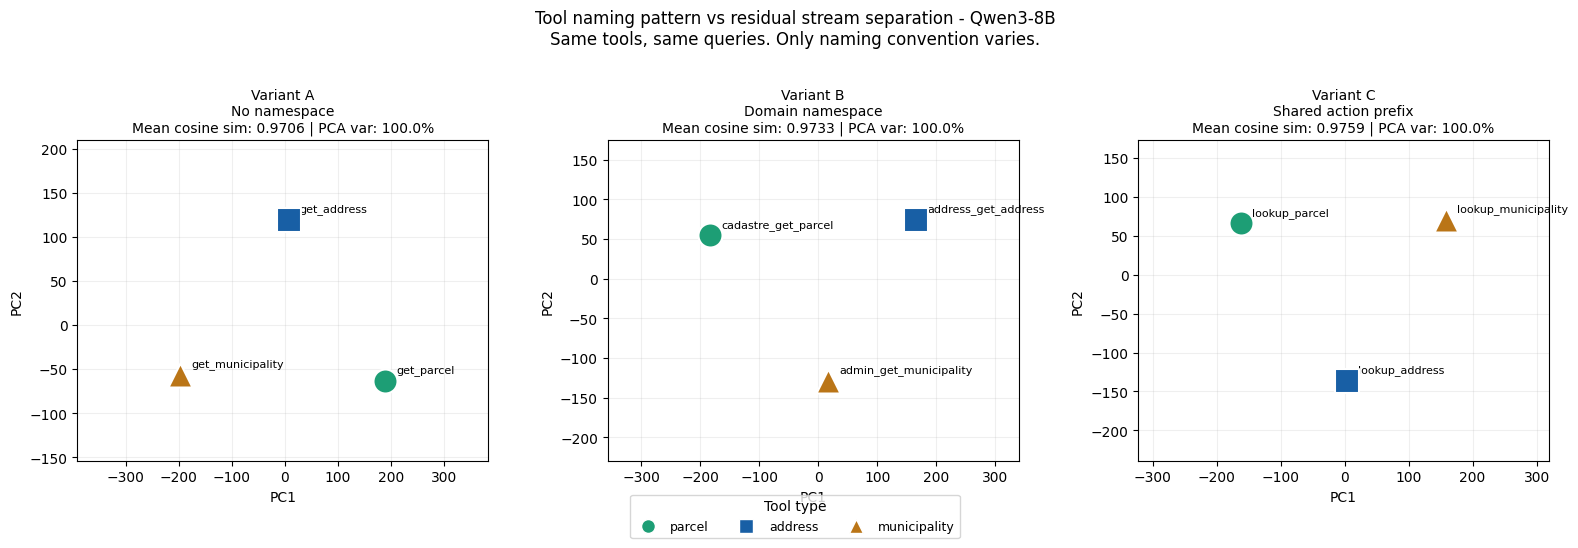

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

variant_labels = {
    "A_no_namespace": "Variant A\nNo namespace",
    "B_domain_namespace": "Variant B\nDomain namespace",
    "C_shared_action_prefix": "Variant C\nShared action prefix",
}

colors = ["#1d9e75", "#185fa5", "#ba7517"]
markers = ["o", "s", "^"]
tool_types = ["parcel", "address", "municipality"]

for ax, (variant_name, tool_means) in zip(axes, all_results.items()):
    names = list(tool_means.keys())
    matrix = np.stack([tool_means[n] for n in names])

    pca = PCA(n_components=2)
    coords = pca.fit_transform(matrix)

    mean_sim = similarity_results[variant_name]["mean_off_diagonal"]

    for i, name in enumerate(names):
        x, y = coords[i]
        ax.scatter(x, y, c=colors[i], s=300,
                   marker=markers[i], zorder=5,
                   edgecolors="white", linewidths=1.5)
        ax.annotate(name, (x, y),
                    textcoords="offset points",
                    xytext=(8, 6), fontsize=8)

    var_explained = sum(pca.explained_variance_ratio_[:2]) * 100

    xs = coords[:, 0]
    ys = coords[:, 1]
    x_pad = (xs.max() - xs.min()) * 0.5 + 1e-6
    y_pad = (ys.max() - ys.min()) * 0.5 + 1e-6
    ax.set_xlim(xs.min() - x_pad, xs.max() + x_pad)
    ax.set_ylim(ys.min() - y_pad, ys.max() + y_pad)

    ax.set_title(
        f"{variant_labels[variant_name]}\n"
        f"Mean cosine sim: {mean_sim:.4f} | "
        f"PCA var: {var_explained:.1f}%",
        fontsize=10
    )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.2)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker=markers[i], color="w",
           markerfacecolor=colors[i], markersize=10,
           label=tool_types[i])
    for i in range(3)
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=3, fontsize=9, title="Tool type",
           bbox_to_anchor=(0.5, -0.05))

fig.suptitle(
    "Tool naming pattern vs residual stream separation - Qwen3-8B\n"
    "Same tools, same queries. Only naming convention varies.",
    fontsize=12, y=1.02
)

plt.tight_layout()
plt.savefig("tool_design_separation.png", dpi=150, bbox_inches="tight")
plt.show()

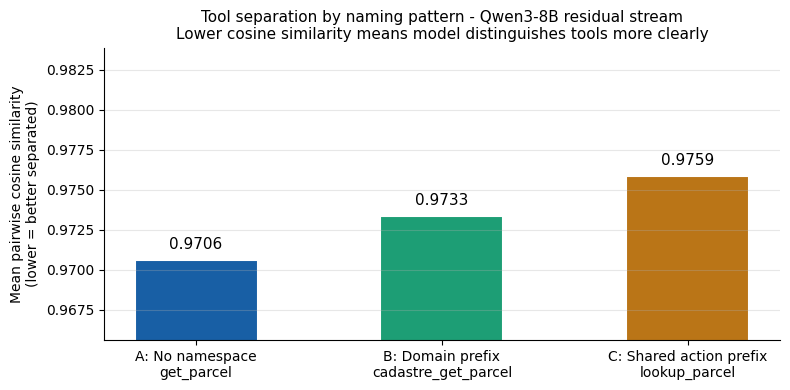

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))

variant_short = {
    "A_no_namespace": "A: No namespace\nget_parcel",
    "B_domain_namespace": "B: Domain prefix\ncadastre_get_parcel",
    "C_shared_action_prefix": "C: Shared action prefix\nlookup_parcel",
}

names = list(similarity_results.keys())
values = [similarity_results[n]["mean_off_diagonal"] for n in names]
labels = [variant_short[n] for n in names]
bar_colors = ["#185fa5", "#1d9e75", "#ba7517"]

bars = ax.bar(labels, values, color=bar_colors, width=0.5,
              edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0005,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=11, fontweight="500"
    )

ax.set_ylabel("Mean pairwise cosine similarity\n(lower = better separated)", fontsize=10)
ax.set_title(
    "Tool separation by naming pattern - Qwen3-8B residual stream\n"
    "Lower cosine similarity means model distinguishes tools more clearly",
    fontsize=11
)
ax.set_ylim(min(values) - 0.005, max(values) + 0.008)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("tool_design_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
best = min(similarity_results.items(),
           key=lambda x: x[1]["mean_off_diagonal"])
worst = max(similarity_results.items(),
            key=lambda x: x[1]["mean_off_diagonal"])

for name, res in similarity_results.items():
    tag = ""
    if name == best[0]:
        tag = " (best separated)"
    if name == worst[0]:
        tag = " (worst separated)"
    print(f"{name}: {res['mean_off_diagonal']:.4f}{tag}")

delta = worst[1]["mean_off_diagonal"] - best[1]["mean_off_diagonal"]
print(f"\nDelta between best and worst: {delta:.4f}")
print(f"Layer: penultimate (same as Wu et al. 2026)")
print(f"Queries per tool: 3")
print(f"Metric: mean pairwise cosine similarity (lower = better separated)")

A_no_namespace: 0.9706(best separated)
B_domain_namespace: 0.9733
C_shared_action_prefix: 0.9759(worst separated)

Delta between best and worst: 0.0052
Layer: penultimate (same as Wu et al. 2026)
Queries per tool: 3
Metric: mean pairwise cosine similarity (lower = better separated)
